<a href="https://colab.research.google.com/github/lukwac123/machine_learning_bootcamp/blob/main/supervised/04_model_selection/02_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
import plotly.express as px

np.random.seed(42)
sns.set(font_scale=1.3)

In [2]:
raw_data = make_moons(n_samples=700, noise=0.25, random_state=42)
data = raw_data[0]
target = raw_data[1]

print(f'{data[:5]}\n')
print(f'{target[:5]}')

[[-0.15995017  1.03638621]
 [ 1.13114102 -0.58763612]
 [ 0.16966619  0.09420938]
 [ 0.51772753  0.81518706]
 [-0.68002085  0.15563468]]

[0 1 1 0 0]


In [3]:
df = pd.DataFrame(data=np.c_[data, target], columns=['x1', 'x2', 'target'])
df.head()

,x1,x2,target
0,-0.159950,1.036386,0.0
1,1.131141,-0.587636,1.0
2,0.169666,0.094209,1.0
3,0.517728,0.815187,0.0
4,-0.680021,0.155635,0.0


In [4]:
px.scatter(df, x='x1', y='x2', color='target', width=700, height=400)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, target)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (525, 2)
X_test shape: (175, 2)
y_train shape: (525,)
y_test shape: (175,)


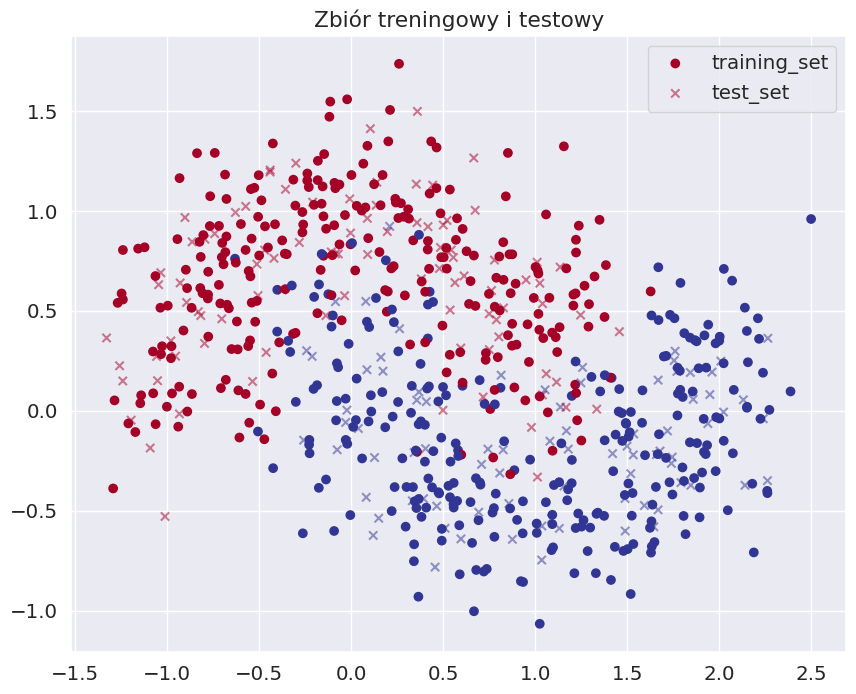

In [7]:
plt.figure(figsize=(10, 8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', label='training_set')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', marker='x', alpha=0.5, label='test_set')
plt.title('Zbiór treningowy i testowy')
plt.legend()
plt.show()

Budowa modelu

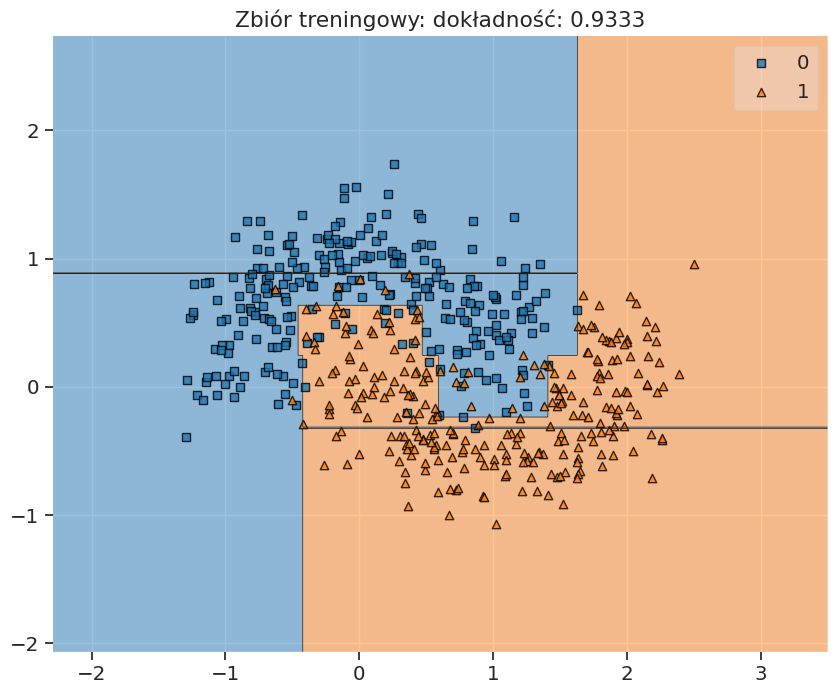

In [8]:
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_decision_regions

classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=5)
classifier.fit(X_train, y_train)

plt.figure(figsize=(10, 8))
plot_decision_regions(X_train, y_train, classifier)
plt.title(f'Zbiór treningowy: dokładność: {classifier.score(X_train, y_train):.4f}')
plt.show()

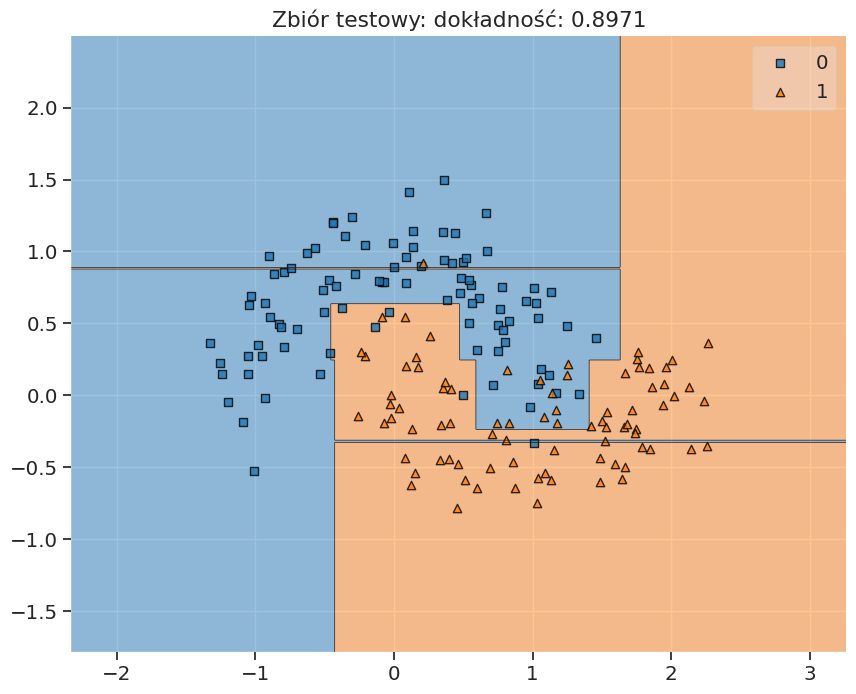

In [9]:
plt.figure(figsize=(10, 8))
plot_decision_regions(X_test, y_test, classifier)
plt.title(f'Zbiór testowy: dokładność: {classifier.score(X_test, y_test):.4f}')
plt.show()

Walidacja krzyżowa

In [10]:
from sklearn.model_selection import cross_val_score

classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=5)

scores = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=10)
scores

array([0.9245283 , 0.90566038, 0.90566038, 0.94339623, 0.90566038,
       0.90384615, 0.82692308, 0.92307692, 0.88461538, 0.90384615])

In [11]:
print(f'Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')

Accuracy: 0.9027 (+/- 0.0294)


In [12]:
classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=5)

scores = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=15)
scores

array([0.94285714, 0.91428571, 0.82857143, 0.94285714, 0.91428571,
       0.91428571, 0.94285714, 0.88571429, 0.88571429, 0.85714286,
       0.88571429, 0.88571429, 0.88571429, 0.91428571, 0.88571429])

In [13]:
print(f'Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')

Accuracy: 0.8990 (+/- 0.0311)


In [14]:
scores = pd.DataFrame(scores, columns=['accuracy'])
scores

,accuracy
0,0.942857
1,0.914286
2,0.828571
3,0.942857
4,0.914286
5,0.914286
6,0.942857
7,0.885714
8,0.885714
9,0.857143


In [20]:
accuracy_scores = scores['accuracy']

px.bar(scores,
       y='accuracy',
       color='accuracy',
       width=700,
       height=400,
       title=f'Walidacja krzyżowa(15 podziałów) | Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std():.3f})',
       color_continuous_scale=px.colors.sequential.Inferno_r,
       range_color=[accuracy_scores.min() - 0.01, 1.0])
